# Basic PyTorch Model: CIFAR-10 Image Classification

This notebook is a compact, complete version of the core PyTorch workflow:

1. Load a real image dataset.
2. Convert examples into tensors and batches.
3. Define models with `nn.Module`.
4. Train with a loss function and optimizer.
5. Evaluate, make predictions, and save/load weights.
6. Preview how image tensors become patch tokens for transformer models.

The dataset is Hugging Face `uoft-cs/cifar10`, a 10-class RGB image classification dataset with 50,000 training images and 10,000 test images. Each image is `32 x 32` pixels.

## 1. Environment Setup

Local usage stays managed by uv from the project root:

```bash
uv run --with jupyter jupyter lab
```

For editor kernels or package installs from inside the notebook, create a project kernel first:

```bash
uv run ipython kernel install --user --env VIRTUAL_ENV $(pwd)/.venv --name=week2
```

On Google Colab, upload this notebook and run cells from the top. The setup cell below detects Colab, installs missing non-PyTorch dependencies into the active Colab runtime with `pip`, and intentionally leaves Colab's built-in `torch` and `torchvision` unchanged to avoid CUDA wheel mismatches.

In [1]:
import importlib.util
import subprocess
import sys


def in_colab() -> bool:
    try:
        return importlib.util.find_spec("google.colab") is not None
    except ModuleNotFoundError:
        return False


def module_available(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None


def run_command(command: list[str]) -> None:
    print("$ " + " ".join(command))
    subprocess.run(command, check=True)


def ensure_colab_dependencies() -> None:
    if not in_colab():
        print("Local environment detected: dependencies are expected from the uv project env.")
        return

    print("Google Colab detected: checking notebook dependencies.")
    missing_torch_modules = [
        name for name in ("torch", "torchvision") if not module_available(name)
    ]
    if missing_torch_modules:
        missing = ", ".join(missing_torch_modules)
        raise RuntimeError(
            f"Missing Colab PyTorch module(s): {missing}. "
            "Use a standard Colab runtime, or manually install matching torch/torchvision "
            "packages for the active CUDA runtime before continuing."
        )

    package_specs = {
        "datasets": "datasets[vision]",
        "matplotlib": "matplotlib",
        "tqdm": "tqdm",
    }
    missing_specs = [spec for module, spec in package_specs.items() if not module_available(module)]
    if not missing_specs:
        print("Colab dependencies are already available.")
        return

    run_command([sys.executable, "-m", "pip", "install", "-q", *missing_specs])
    print("Installed missing Colab dependencies: " + ", ".join(missing_specs))


ensure_colab_dependencies()

Local environment detected: dependencies are expected from the uv project env.


In [2]:
import platform
import random
import time
from collections.abc import Mapping, Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

Metrics = dict[str, float | int]


def print_section(title: str, rows: Mapping[str, object]) -> None:
    label_width = max(len(label) for label in rows)
    print(f"\n{title}")
    print("-" * len(title))
    for label, value in rows.items():
        print(f"{label:<{label_width}} : {value}")


def format_shape(tensor: torch.Tensor) -> str:
    return " x ".join(str(size) for size in tensor.shape)


SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

environment_name = "Google Colab" if in_colab() else "local uv"
print_section(
    "Runtime",
    {
        "Environment": environment_name,
        "Python": platform.python_version(),
        "PyTorch": torch.__version__,
        "Device": device,
        "Seed": SEED,
    },
)

/home/rvl/chiwei/summer_course/week2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Runtime
-------
Environment : local uv
Python      : 3.14.0
PyTorch     : 2.12.1+cu126
Device      : cuda
Seed        : 42


## 2. Load CIFAR-10 from Hugging Face

Hugging Face Datasets stores images as PIL images until they are decoded. We will attach transforms that convert each image into a normalized PyTorch tensor only when an example is read.

In [3]:
raw_datasets = load_dataset("uoft-cs/cifar10")
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


CIFAR-10 dataset
----------------
Splits        : train, test
Train rows    : 50,000
Test rows     : 10,000
Classes       : 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
Example image : RGB 32 x 32
Example label : 0 = airplane


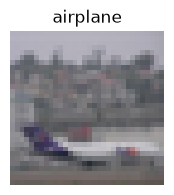

In [4]:
label_feature = raw_datasets["train"].features["label"]
class_names = label_feature.names
num_classes = len(class_names)
raw_example = raw_datasets["train"][0]
example_image = raw_example["img"]
example_label = raw_example["label"]

print_section(
    "CIFAR-10 dataset",
    {
        "Splits": ", ".join(raw_datasets.keys()),
        "Train rows": f"{len(raw_datasets['train']):,}",
        "Test rows": f"{len(raw_datasets['test']):,}",
        "Classes": f"{num_classes} ({', '.join(class_names)})",
        "Example image": f"{example_image.mode} {example_image.width} x {example_image.height}",
        "Example label": f"{example_label} = {class_names[example_label]}",
    },
)

plt.figure(figsize=(2, 2))
plt.imshow(example_image)
plt.title(class_names[example_label])
plt.axis("off")
plt.show()

## 3. Transforms and DataLoaders

CIFAR-10 images are small RGB images. The model will receive tensors shaped `[channels, height, width]`, so a batch has shape `[batch, channels, height, width]`.

The normalization values below are the standard CIFAR-10 channel means and standard deviations. Normalization usually makes optimization easier because the model sees inputs centered around a stable range.

In [5]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ]
)


def transform_train(batch: dict[str, list]) -> dict[str, list]:
    batch["pixel_values"] = [train_transform(image.convert("RGB")) for image in batch["img"]]
    return batch


def transform_eval(batch: dict[str, list]) -> dict[str, list]:
    batch["pixel_values"] = [eval_transform(image.convert("RGB")) for image in batch["img"]]
    return batch


train_dataset = raw_datasets["train"].with_transform(transform_train)
test_dataset = raw_datasets["test"].with_transform(transform_eval)

In [6]:
def collate_fn(batch: list[dict[str, torch.Tensor | int]]) -> tuple[torch.Tensor, torch.Tensor]:
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    labels = torch.tensor([example["label"] for example in batch], dtype=torch.long)
    return pixel_values, labels


def format_label_preview(labels: torch.Tensor, class_names: Sequence[str], limit: int = 8) -> str:
    pairs = [f"{label.item()}={class_names[label.item()]}" for label in labels[:limit]]
    return ", ".join(pairs)


batch_size = 128
pin_memory = device.type == "cuda"
# Keep notebook DataLoaders single-process so Python 3.14/Jupyter can run
# Hugging Face transform functions without multiprocessing pickling issues.
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

images, labels = next(iter(train_loader))
print_section(
    "Batch check",
    {
        "Images": f"{format_shape(images)} ({images.dtype})",
        "Labels": f"{format_shape(labels)} ({labels.dtype})",
        "Preview": format_label_preview(labels, class_names),
        "Batch size": batch_size,
        "Pin memory": pin_memory,
    },
)


Batch check
-----------
Images     : 128 x 3 x 32 x 32 (torch.float32)
Labels     : 128 (torch.int64)
Preview    : 5=dog, 1=automobile, 5=dog, 8=ship, 3=cat, 2=bird, 9=truck, 1=automobile
Batch size : 128
Pin memory : True


## 4. Visualize a Batch

The model sees normalized tensors, but humans need the values converted back into displayable pixel ranges.

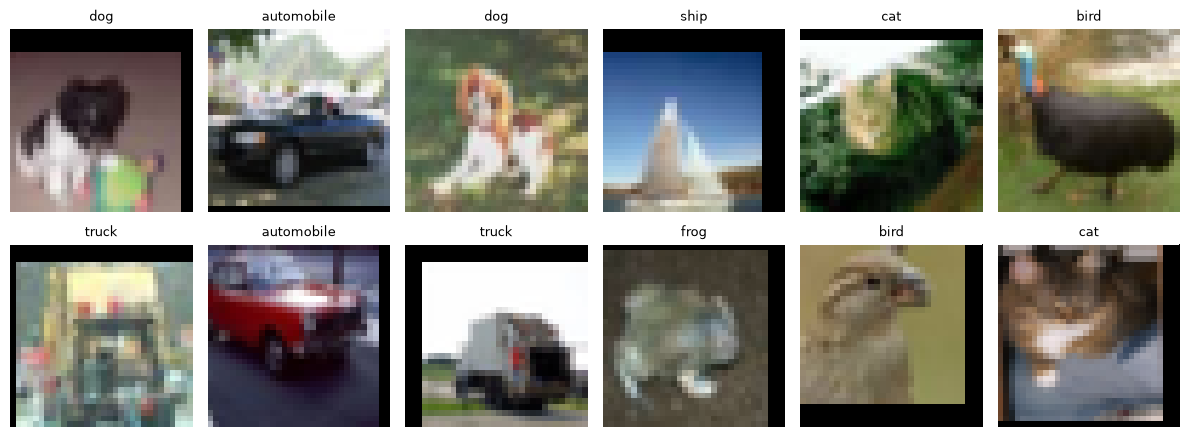

In [7]:
def denormalize(images: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR10_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(1, 3, 1, 1)
    return (images.cpu() * std + mean).clamp(0, 1)


def show_images(
    images: torch.Tensor,
    labels: torch.Tensor,
    predictions: torch.Tensor | None = None,
    max_images: int = 12,
) -> None:
    display_images = denormalize(images[:max_images])
    display_labels = labels[:max_images].cpu()
    display_predictions = predictions[:max_images].cpu() if predictions is not None else None

    cols = 6
    rows = (len(display_images) + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(12, 2.3 * rows))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for i, image in enumerate(display_images):
        axes[i].imshow(image.permute(1, 2, 0))
        label_name = class_names[display_labels[i].item()]
        if display_predictions is None:
            title = label_name
        else:
            pred_name = class_names[display_predictions[i].item()]
            marker = "OK" if pred_name == label_name else "MISS"
            title = f"{marker}: {pred_name}\ntrue: {label_name}"
        axes[i].set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()


show_images(images, labels)

## 5. Model 1: A Linear Baseline

A neural network maps input tensors to logits. Logits are raw class scores; `CrossEntropyLoss` combines `log_softmax` and negative log-likelihood, so we pass logits directly to the loss.

The linear baseline flattens each image from `[3, 32, 32]` into `3072` numbers and applies one learned linear classifier.

In [8]:
class LinearImageClassifier(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(3 * 32 * 32, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        logits = self.classifier(x)
        return logits


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def print_model_snapshot(
    name: str,
    model: nn.Module,
    input_batch: torch.Tensor,
    logits: torch.Tensor,
) -> None:
    print_section(
        name,
        {
            "Trainable params": f"{count_parameters(model):,}",
            "Input batch": format_shape(input_batch),
            "Output logits": format_shape(logits),
            "Model": model.__class__.__name__,
        },
    )


linear_model = LinearImageClassifier(num_classes).to(device)
with torch.inference_mode():
    logits = linear_model(images.to(device))

print_model_snapshot("Linear baseline", linear_model, images, logits)


Linear baseline
---------------
Trainable params : 30,730
Input batch      : 128 x 3 x 32 x 32
Output logits    : 128 x 10
Model            : LinearImageClassifier


## 6. Training and Evaluation Helpers

A PyTorch training loop has the same essential steps every time:

1. Move a batch to the device.
2. Run the model forward.
3. Compute the loss.
4. Clear old gradients.
5. Backpropagate.
6. Update parameters.

Evaluation disables gradient tracking and does not update parameters.

In [9]:
def accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    predictions = logits.argmax(dim=1)
    return (predictions == labels).sum()


def dataloader_steps(dataloader: DataLoader, max_batches: int | None = None) -> int:
    steps = len(dataloader)
    return steps if max_batches is None else min(steps, max_batches)


def progress_postfix(
    total_loss: torch.Tensor, total_correct: torch.Tensor, total_examples: int
) -> dict[str, str]:
    return {
        "loss": f"{total_loss.item() / total_examples:.4f}",
        "acc": f"{total_correct.item() / total_examples:.2%}",
    }


def run_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
    max_batches: int | None = None,
    description: str = "epoch",
) -> Metrics:
    model.train(optimizer is not None)
    total_loss = torch.zeros((), device=device)
    total_correct = torch.zeros((), device=device)
    total_examples = 0
    start = time.perf_counter()
    steps = dataloader_steps(dataloader, max_batches)
    progress = tqdm(dataloader, total=steps, desc=description, leave=False)

    with torch.set_grad_enabled(optimizer is not None):
        for batch_idx, (images, labels) in enumerate(progress):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = loss_fn(logits, labels)

            if optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.detach() * batch_size
            total_correct += accuracy_from_logits(logits, labels)
            total_examples += batch_size
            if batch_idx % 20 == 0:
                progress.set_postfix(progress_postfix(total_loss, total_correct, total_examples))

    return {
        "loss": total_loss.item() / total_examples,
        "accuracy": total_correct.item() / total_examples,
        "examples": total_examples,
        "seconds": time.perf_counter() - start,
    }


def train_model(
    model: nn.Module,
    train_dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int,
    eval_dataloader: DataLoader | None = None,
    max_train_batches: int | None = None,
    max_eval_batches: int | None = None,
) -> list[dict[str, Metrics]]:
    history: list[dict[str, Metrics]] = []

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            model,
            train_dataloader,
            loss_fn,
            device,
            optimizer=optimizer,
            max_batches=max_train_batches,
            description=f"epoch {epoch}/{epochs} train",
        )
        epoch_metrics = {"train": train_metrics}
        if eval_dataloader is not None:
            epoch_metrics["test"] = run_epoch(
                model,
                eval_dataloader,
                loss_fn,
                device,
                max_batches=max_eval_batches,
                description=f"epoch {epoch}/{epochs} eval",
            )

        history.append(epoch_metrics)
        tqdm.write(format_metrics_summary(epoch, epochs, epoch_metrics))

    return history


def format_metrics_summary(epoch: int, epochs: int, rows: Mapping[str, Metrics]) -> str:
    parts = [f"Epoch {epoch}/{epochs}"]
    for name, metrics in rows.items():
        summary = f"{name}: loss={metrics['loss']:.4f}, acc={metrics['accuracy']:.2%}"
        if "seconds" in metrics:
            summary += f", time={metrics['seconds']:.1f}s"
        parts.append(summary)
    return " | ".join(parts)

## 7. Train the Linear Baseline

The linear model is intentionally weak for images because it ignores spatial structure. It is useful because it exposes the full supervised learning pipeline with the smallest possible model.

In [10]:
linear_epochs = 1
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(linear_model.parameters(), lr=1e-3)

linear_history = train_model(
    linear_model,
    train_loader,
    loss_fn,
    optimizer,
    device,
    epochs=linear_epochs,
    eval_dataloader=test_loader,
)

Epoch 1/1 | train: loss=2.0791, acc=27.88%, time=14.5s | test: loss=1.9612, acc=33.17%, time=2.1s


## 8. Model 2: A Small Convolutional Network

Convolutional layers preserve spatial structure. Each convolution learns local filters, and pooling reduces resolution while keeping useful features. This is the image-modeling idea that comes before Vision Transformers.

In [11]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        logits = self.classifier(x)
        return logits


cnn_model = SmallCNN(num_classes).to(device)
with torch.inference_mode():
    logits = cnn_model(images.to(device))

print_model_snapshot("Small CNN", cnn_model, images, logits)


Small CNN
---------
Trainable params : 141,354
Input batch      : 128 x 3 x 32 x 32
Output logits    : 128 x 10
Model            : SmallCNN


## 9. Train the CNN

One epoch is enough to verify the full workflow. For better accuracy, increase `cnn_epochs` to 3-10 and train on a GPU.

In [12]:
cnn_epochs = 1
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=3e-4, weight_decay=1e-4)

cnn_history = train_model(
    cnn_model,
    train_loader,
    loss_fn,
    optimizer,
    device,
    epochs=cnn_epochs,
    eval_dataloader=test_loader,
)

Epoch 1/1 | train: loss=1.5544, acc=44.39%, time=15.2s | test: loss=1.3023, acc=53.22%, time=2.1s


## 10. Predictions

The final class prediction is the index of the largest logit. If we want probabilities, we apply `softmax` after the model. We do not apply `softmax` before `CrossEntropyLoss` during training.


First test image top-3
----------------------
frog : 23.30%
cat  : 22.04%
bird : 17.77%


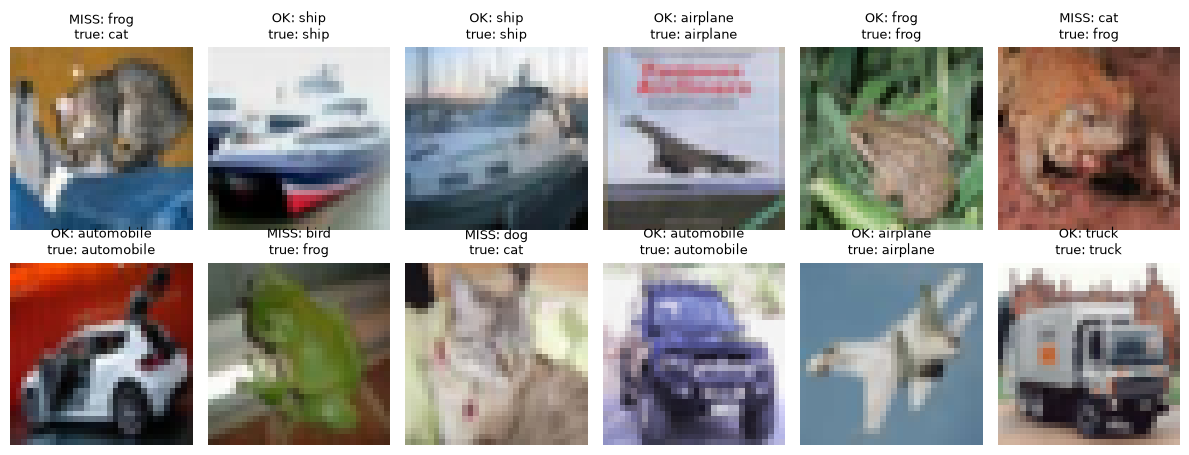

In [13]:
@torch.inference_mode()
def predict_batch(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    logits = model(images.to(device))
    probabilities = torch.softmax(logits, dim=1)
    predictions = probabilities.argmax(dim=1)
    return predictions.cpu(), probabilities.cpu()


test_images, test_labels = next(iter(test_loader))
predictions, probabilities = predict_batch(cnn_model, test_images, device)

top_scores, top_indices = torch.topk(probabilities[0], k=3)
print_section(
    "First test image top-3",
    {
        class_names[class_idx.item()]: f"{score.item():.2%}"
        for score, class_idx in zip(top_scores, top_indices, strict=True)
    },
)

show_images(test_images, test_labels, predictions=predictions, max_images=12)

## 11. Save and Load Model Weights

A common PyTorch pattern is to save only the `state_dict`, which contains learned parameter tensors. To load it later, recreate the same model class and load the state dictionary.

In [14]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
weights_path = model_dir / "small_cnn_cifar10.pt"

torch.save(cnn_model.state_dict(), weights_path)

reloaded_model = SmallCNN(num_classes).to(device)
reloaded_model.load_state_dict(torch.load(weights_path, map_location=device))
reloaded_model.eval()

with torch.inference_mode():
    reloaded_logits = reloaded_model(test_images.to(device))

print_section(
    "Saved model weights",
    {
        "Path": weights_path,
        "Reloaded logits": format_shape(reloaded_logits),
        "Expected logits": f"{test_images.size(0)} x {num_classes}",
    },
)
assert reloaded_logits.shape == (test_images.size(0), num_classes)


Saved model weights
-------------------
Path            : models/small_cnn_cifar10.pt
Reloaded logits : 128 x 10
Expected logits : 128 x 10


## 12. Bridge to Transformers: Images as Patch Tokens

Vision Transformers do not start with convolutions. They split an image into fixed-size patches, flatten each patch, then map each patch into an embedding vector.

For CIFAR-10 images shaped `[B, 3, 32, 32]`, patch size `4 x 4` gives:

- `32 / 4 = 8` patches per side
- `8 * 8 = 64` patches per image
- each raw patch has `3 * 4 * 4 = 48` values

So the patch-token tensor has shape `[B, 64, 48]` before the learned embedding layer.

In [15]:
def image_to_patch_tokens(images: torch.Tensor, patch_size: int = 4) -> torch.Tensor:
    batch, channels, height, width = images.shape
    assert height % patch_size == 0 and width % patch_size == 0

    patches = images.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.permute(0, 2, 3, 1, 4, 5)
    tokens = patches.reshape(batch, -1, channels * patch_size * patch_size)
    return tokens


patch_tokens = image_to_patch_tokens(test_images, patch_size=4)
print_section(
    "Patch tokens",
    {
        "Image batch": format_shape(test_images),
        "Patch size": "4 x 4",
        "Patch tokens": format_shape(patch_tokens),
        "Tokens/image": patch_tokens.size(1),
        "Values/token": patch_tokens.size(2),
    },
)
assert patch_tokens.shape == (test_images.size(0), 64, 48)


Patch tokens
------------
Image batch  : 128 x 3 x 32 x 32
Patch size   : 4 x 4
Patch tokens : 128 x 64 x 48
Tokens/image : 64
Values/token : 48


## What You Should Be Ready For Next

After this notebook, you should be comfortable with these ideas before moving to transformers:

- A model consumes tensors and returns logits.
- Batching adds a leading batch dimension.
- Loss functions compare logits against target labels.
- Optimizers update parameters using gradients.
- Image tensors can be treated either as spatial grids for CNNs or as patch-token sequences for transformers.